In [1]:
from data_processing import DataSetup

flight_matrix_path = 'pgfgleam/datasets/country_flow_202001 1.csv'
country_codes_path = 'pgfgleam/datasets/geom_countries_codes.csv'
population_path = 'pgfgleam/datasets/WPP2019_TotalPopulation2020.csv'

flight_matrix, normalized_flow_matrix, source_countries, target_countries, source_codes, target_codes, population, name_mapping = DataSetup(flight_matrix_path, population_path, country_codes_path).load_and_process_data().values()


/Users/reddy/AWW_and_ICU/wastewater_venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-15 10:05:47,823	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Highlighting manually selected countries: ['Nigeria', 'United Arab Emirates', 'Ghana', 'Poland', 'Botswana']


Computing Simulation: 100%|██████████| 101/101 [11:53<00:00,  7.06s/it]


FileNotFoundError: [Errno 2] No such file or directory: '/Users/reddy/figures/manual_highlight_detection_analysis_Nigeria_new.pdf'

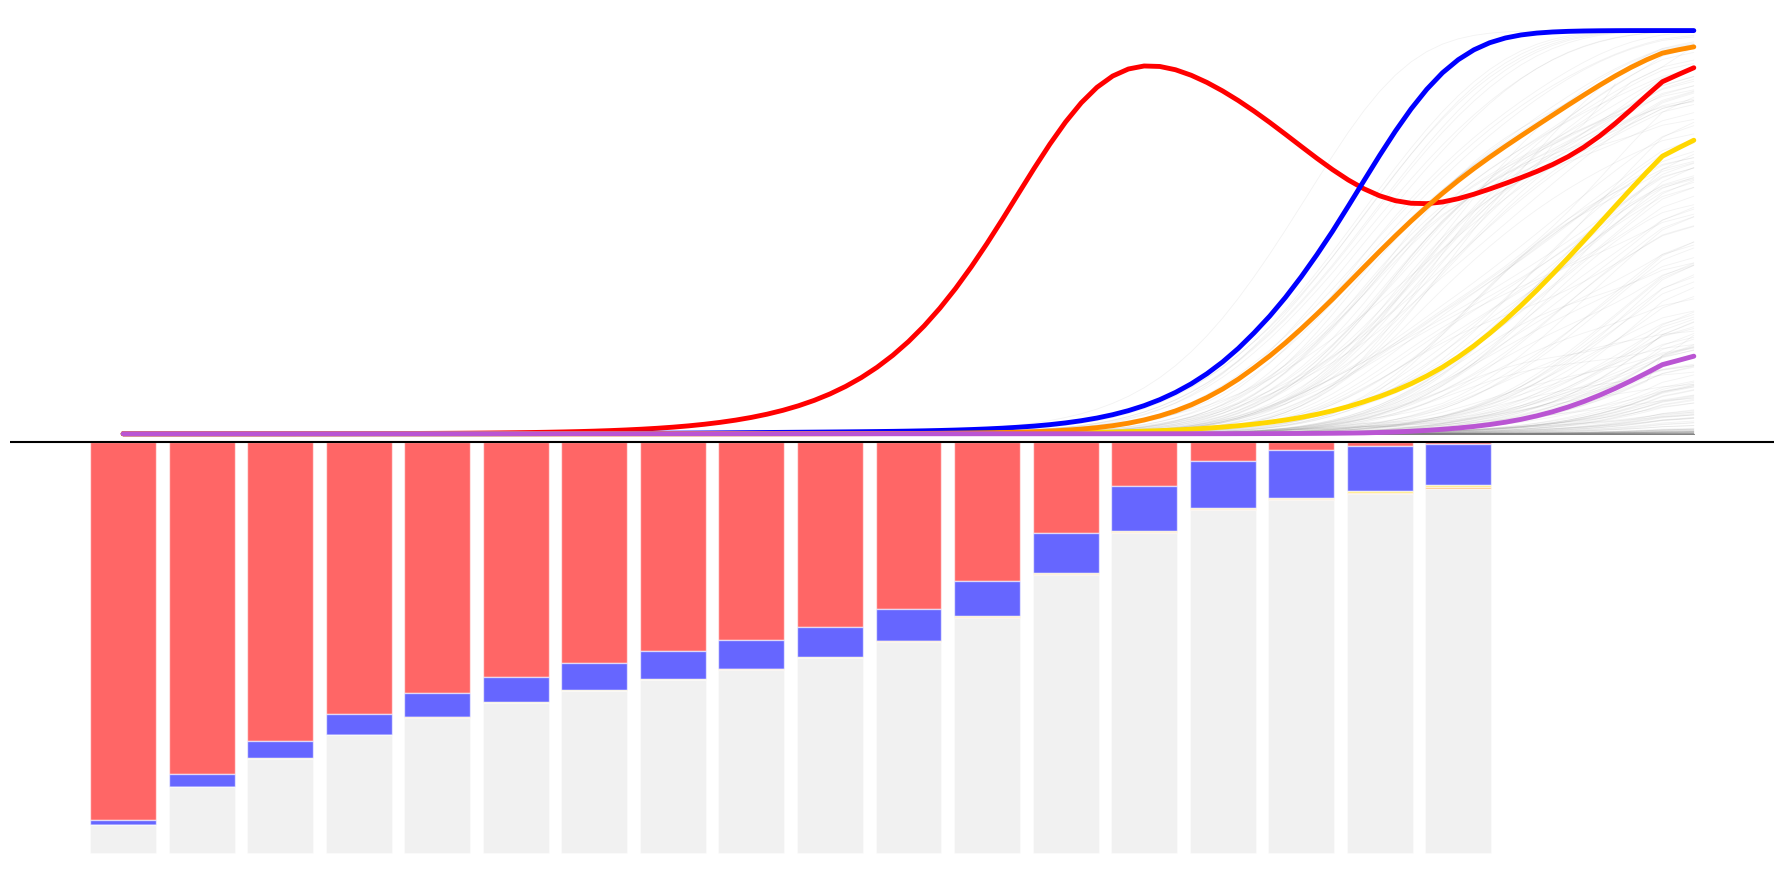

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 1. MANUAL SELECTION ---
origin_name = 'Nigeria'
target_name = 'United Kingdom'

# Manually list the countries you want to highlight
highlight_list = ['Nigeria', 'United Arab Emirates', "Ghana", 'Poland', 'Botswana']

# Assign them to your color-coded slots for consistency in your head
c1, c2, c3, c4, c5 = highlight_list

print(f"Highlighting manually selected countries: {highlight_list}")

# --- 2. Simulation Setup ---
alpha, detect_prob, top_k_sources = 0.02, 0.16, 12
max_time = 100 

# Old legacy version I used; I haven't added the daily_imports_full.csv which you can obtain from global_model.ipynb
# imports_df = pd.read_csv('UK_Detect/pgfgleam/new_all_daily_imports_0.16_fixed.csv')
imports_df = pd.read_csv('pgfgleam/all_results/global/daily_imports_full.csv')


all_times = sorted(imports_df['time'].unique())
all_times = [t for t in all_times if t <= max_time]
all_countries = sorted(imports_df['import_country'].unique())

time_series_data = {c: [] for c in all_countries}
relative_risk_data = {c: [] for c in all_countries}

# --- 3. Simulation Loop (Processing All for Background/Other data) ---
for current_time in tqdm(all_times, desc="Computing Simulation"):
    time_data = imports_df[imports_df['time'] == current_time]
    outbreak_source_data = time_data[time_data['import_country'] == origin_name]
    
    if outbreak_source_data.empty:
        for c in all_countries:
            time_series_data[c].append(alpha); relative_risk_data[c].append(0)
        continue
    
    outbreak_likelihoods = []
    for _, row in outbreak_source_data.iterrows():
        lik = 1 - (1 - detect_prob) ** row['daily_detectable_imports'] if row['daily_detectable_imports'] > 0 else 1e-10
        outbreak_likelihoods.append({'source': row['outbreak_country'], 'lik': lik})
    
    outbreak_likelihoods.sort(key=lambda x: x['lik'], reverse=True)
    top_sources = outbreak_likelihoods[:top_k_sources]
    total_weight = sum([x['lik'] for x in top_sources])

    for val_origin in all_countries:
        w_prob, w_risk = 0, 0
        for src in top_sources:
            weight = src['lik'] / total_weight if total_weight > 0 else 1/len(top_sources)
            v_data = time_data[(time_data['outbreak_country'] == src['source']) & (time_data['import_country'] == val_origin)]
            v_imp = v_data['daily_detectable_imports'].iloc[0] if not v_data.empty else 0
            
            p_true = 1 - (1 - detect_prob) ** v_imp
            w_prob += weight * (p_true + alpha * (1 - p_true))
            w_risk += weight * v_imp
            
        time_series_data[val_origin].append(w_prob)
        relative_risk_data[val_origin].append(w_risk)

# --- 4. Post-Processing (Smoothing & Binning) ---
window_size = 5
for c in all_countries:
    time_series_data[c] = pd.Series(time_series_data[c]).rolling(
        window=window_size, 
        center=True, 
        min_periods=1
    ).mean().tolist()
    
time_bins = list(range(0, max_time + 1, 5))
bar_positions = time_bins[:-1]
bar_width = 5
binned_risk = {c: [] for c in highlight_list + ['Other']}

for i in range(len(time_bins)-1):
    idx = [j for j, t in enumerate(all_times) if time_bins[i] <= t < time_bins[i+1]]
    total_bin_risk = sum(np.mean([relative_risk_data[c][k] for k in idx]) for c in all_countries) if idx else 0
    
    other_acc = 0
    for c in all_countries:
        val = np.mean([relative_risk_data[c][k] for k in idx]) / total_bin_risk if total_bin_risk > 0 else 0
        if c in highlight_list:
            binned_risk[c].append(val)
        else:
            other_acc += val
    binned_risk['Other'].append(other_acc)

# --- 5. Plotting ---
sns.set(style='white')
fig, ax = plt.subplots(figsize=(18, 9))

# Plot all background lines
for c in all_countries:
    ax.plot(all_times, time_series_data[c], alpha=0.1, color='gray', lw=0.6, zorder=1)

# Plot manually selected curves
colors = ['red', 'blue', 'gold', 'darkorange', 'mediumorchid']
for i, c in enumerate(highlight_list):
    ax.plot(all_times, time_series_data[c], color=colors[i], lw=3.5, zorder=3)

# Plot manually selected bars
bottom = np.zeros(len(bar_positions))
for i, c in enumerate(highlight_list):
    ax.bar(bar_positions, -np.array(binned_risk[c]), bottom=-bottom, color=colors[i], alpha=0.6, width=4.2, zorder=2)
    bottom += np.array(binned_risk[c])

# Plot the 'Other' bars (everyone else)
ax.bar(bar_positions, -np.array(binned_risk['Other']), bottom=-bottom, color='lightgray', alpha=0.3, width=4.2, zorder=2)

ax.axhline(0, color='black', lw=1.5)
ax.set_xticks([]); ax.set_yticks([]); sns.despine(left=True, bottom=True)
ax.set_ylim(-1.05, 1.05)
plt.tight_layout()
plt.savefig('/Users/reddy/figures/manual_highlight_detection_analysis_Nigeria_new.pdf', dpi=300, bbox_inches='tight')
plt.show()

Highlighting manually selected countries: ['Nigeria', 'United Arab Emirates', 'Ghana', 'Poland', 'Botswana']


Computing Outbreak Origin Likelihoods:   6%|▌         | 7/121 [00:00<00:04, 27.98it/s]


Day 0.000000:
  1. Democratic Republic of the Congo   0.9550 (95.50%)
  2. Afghanistan                      0.0002 ( 0.02%)
  3. Albania                          0.0002 ( 0.02%)
  4. Algeria                          0.0002 ( 0.02%)
  5. Andorra                          0.0002 ( 0.02%)
  6. Angola                           0.0002 ( 0.02%)
  7. Anguilla                         0.0002 ( 0.02%)
  8. Antarctica                       0.0002 ( 0.02%)
  9. Antigua and Barbuda              0.0002 ( 0.02%)
  10. Argentina                        0.0002 ( 0.02%)

Day 10.000000:
  1. Democratic Republic of the Congo   0.9996 (99.96%)
  2. Gabon                            0.0001 ( 0.01%)
  3. Belgium                          0.0000 ( 0.00%)
  4. Cyprus                           0.0000 ( 0.00%)
  5. Ethiopia                         0.0000 ( 0.00%)
  6. Switzerland                      0.0000 ( 0.00%)
  7. United Arab Emirates             0.0000 ( 0.00%)
  8. Mauritius                        0.0000 (

Computing Outbreak Origin Likelihoods:  22%|██▏       | 27/121 [00:00<00:01, 51.58it/s]


Day 20.000000:
  1. Democratic Republic of the Congo   0.9991 (99.91%)
  2. Gabon                            0.0002 ( 0.02%)
  3. Belgium                          0.0001 ( 0.01%)
  4. Ethiopia                         0.0001 ( 0.01%)
  5. Seychelles                       0.0001 ( 0.01%)
  6. Congo                            0.0000 ( 0.00%)
  7. Lebanon                          0.0000 ( 0.00%)
  8. South Africa                     0.0000 ( 0.00%)
  9. Cyprus                           0.0000 ( 0.00%)
  10. Rwanda                           0.0000 ( 0.00%)

Day 30.000000:
  1. Democratic Republic of the Congo   0.9986 (99.86%)
  2. Gabon                            0.0003 ( 0.03%)
  3. Belgium                          0.0002 ( 0.02%)
  4. Ethiopia                         0.0001 ( 0.01%)
  5. Congo                            0.0001 ( 0.01%)
  6. Lebanon                          0.0001 ( 0.01%)
  7. Seychelles                       0.0001 ( 0.01%)
  8. Rwanda                           0.0001 

...


Day 80.000000:
  1. Democratic Republic of the Congo   0.9863 (98.63%)
  2. Gabon                            0.0027 ( 0.27%)
  3. Belgium                          0.0016 ( 0.16%)
  4. Congo                            0.0007 ( 0.07%)
  5. Lebanon                          0.0007 ( 0.07%)
  6. Ethiopia                         0.0007 ( 0.07%)
  7. Rwanda                           0.0006 ( 0.06%)
  8. South Africa                     0.0005 ( 0.05%)
  9. Seychelles                       0.0005 ( 0.05%)
  10. Switzerland                      0.0004 ( 0.04%)

Day 90.000000:
  1. Democratic Republic of the Congo   0.9126 (91.26%)
  2. Gabon                            0.0167 ( 1.67%)
  3. Belgium                          0.0098 ( 0.98%)
  4. Congo                            0.0047 ( 0.47%)
  5. Lebanon                          0.0042 ( 0.42%)
  6. Ethiopia                         0.0042 ( 0.42%)
  7. Rwanda                           0.0040 ( 0.40%)
  8. South Africa                     0.0034 

Computing Outbreak Origin Likelihoods:  92%|█████████▏| 111/121 [00:01<00:00, 63.11it/s]


Day 100.000000:
  1. Democratic Republic of the Congo   0.5989 (59.89%)
  2. Gabon                            0.0735 ( 7.35%)
  3. Belgium                          0.0436 ( 4.36%)
  4. Congo                            0.0215 ( 2.15%)
  5. Lebanon                          0.0193 ( 1.93%)
  6. Ethiopia                         0.0189 ( 1.89%)
  7. Rwanda                           0.0182 ( 1.82%)
  8. South Africa                     0.0155 ( 1.55%)
  9. Seychelles                       0.0135 ( 1.35%)
  10. Switzerland                      0.0112 ( 1.12%)

Day 110.000000:
  1. Democratic Republic of the Congo   0.1920 (19.20%)
  2. Gabon                            0.1151 (11.51%)
  3. Belgium                          0.0781 ( 7.81%)
  4. Congo                            0.0435 ( 4.35%)
  5. Lebanon                          0.0392 ( 3.92%)
  6. Ethiopia                         0.0383 ( 3.83%)
  7. Rwanda                           0.0374 ( 3.74%)
  8. South Africa                     0.032

Computing Outbreak Origin Likelihoods: 100%|██████████| 121/121 [00:02<00:00, 55.89it/s]



Day 120.000000:
  1. Democratic Republic of the Congo   0.0496 ( 4.96%)
  2. Gabon                            0.0495 ( 4.95%)
  3. Belgium                          0.0482 ( 4.82%)
  4. Congo                            0.0413 ( 4.13%)
  5. Lebanon                          0.0394 ( 3.94%)
  6. Ethiopia                         0.0389 ( 3.89%)
  7. Rwanda                           0.0386 ( 3.86%)
  8. South Africa                     0.0356 ( 3.56%)
  9. Seychelles                       0.0318 ( 3.18%)
  10. Kenya                            0.0292 ( 2.92%)



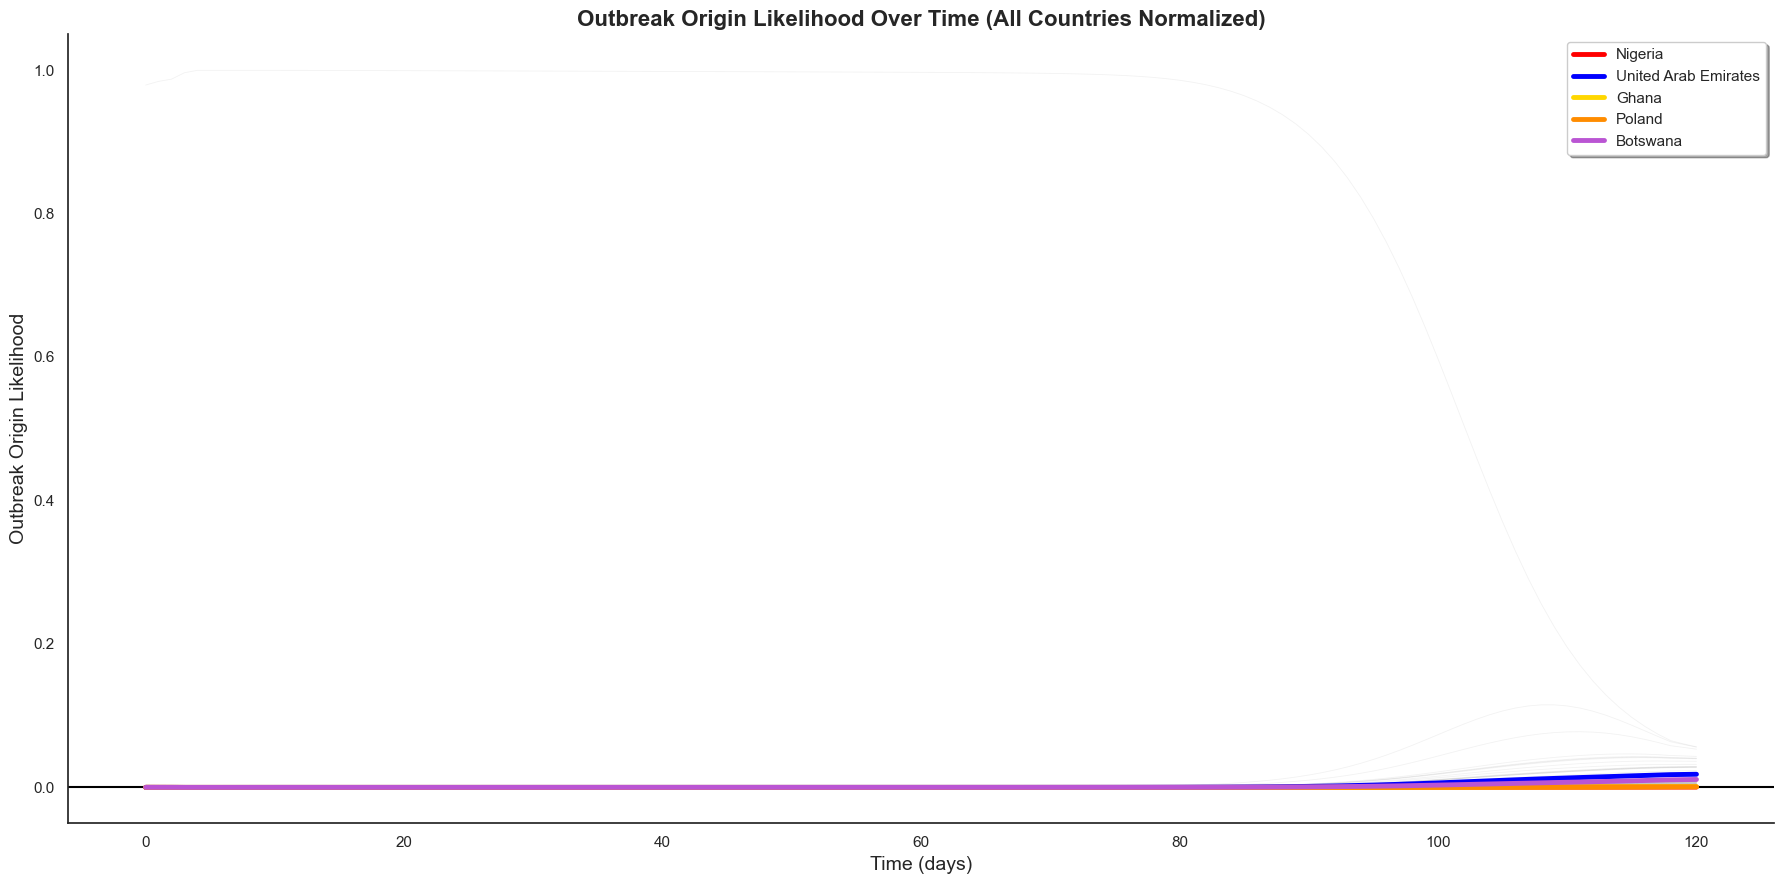

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# imports_df = pd.read_csv('UK_Detect/pgfgleam/new_all_daily_imports_0.16_fixed.csv')
imports_df = pd.read_csv('pgfgleam/all_results/global/daily_imports_full.csv')

origin_name = 'Democratic Republic of the Congo'
target_name = 'United Kingdom'

# Manually list the countries you want to highlight
highlight_list = ['Nigeria', 'United Arab Emirates', 'Ghana', 'Poland', 'Botswana'] 

# Assign them to your color-coded slots for consistency
c1, c2, c3, c4, c5 = highlight_list

print(f"Highlighting manually selected countries: {highlight_list}")

alpha, detect_prob, top_k_sources = 0.02, 0.16, 12
max_time = 120 

all_times = sorted(imports_df['time'].unique())
all_times = [t for t in all_times if t <= max_time]
all_countries = sorted(imports_df['import_country'].unique())

# Store outbreak origin likelihoods over time
outbreak_likelihood_data = {c: [] for c in all_countries}

for current_time in tqdm(all_times, desc="Computing Outbreak Origin Likelihoods"):
    time_data = imports_df[imports_df['time'] == current_time]
    outbreak_source_data = time_data[time_data['import_country'] == origin_name]
    
    if outbreak_source_data.empty:
        for c in all_countries:
            outbreak_likelihood_data[c].append(1.0 / len(all_countries))  # Equal likelihood
        continue
    
    # Calculate outbreak origin likelihoods for each country
    outbreak_likelihoods = {}
    for _, row in outbreak_source_data.iterrows():
        lik = 1 - (1 - detect_prob) ** row['daily_detectable_imports'] if row['daily_detectable_imports'] > 0 else 1e-10
        outbreak_likelihoods[row['outbreak_country']] = lik
    
    # Normalize across ALL countries (not just top-k)
    total_weight = sum(outbreak_likelihoods.values())
    
    # Store normalized likelihoods for all countries
    current_likelihoods = {}
    for c in all_countries:
        if c in outbreak_likelihoods:
            normalized_lik = outbreak_likelihoods[c] / total_weight if total_weight > 0 else 1.0 / len(all_countries)
        else:
            normalized_lik = 0  # Or could assign a small uniform probability
        outbreak_likelihood_data[c].append(normalized_lik)
        current_likelihoods[c] = normalized_lik
    
    # Print top 5 at every multiple of 10 days
    if current_time % 10 == 0:
        top_10 = sorted(current_likelihoods.items(), key=lambda x: x[1], reverse=True)[:10]
        print(f"\nDay {current_time:3f}:")
        for rank, (country, likelihood) in enumerate(top_10, 1):
            print(f"  {rank}. {country:30s} {likelihood:8.4f} ({likelihood*100:5.2f}%)")

window_size = 5
for c in all_countries:
    outbreak_likelihood_data[c] = pd.Series(outbreak_likelihood_data[c]).rolling(
        window=window_size, 
        center=True, 
        min_periods=1
    ).mean().tolist()

print("\n" + "="*80)

sns.set(style='white')
fig, ax = plt.subplots(figsize=(18, 9))

for c in all_countries:
    ax.plot(all_times, outbreak_likelihood_data[c], alpha=0.1, color='gray', lw=0.6, zorder=1)

colors = ['red', 'blue', 'gold', 'darkorange', 'mediumorchid']
for i, c in enumerate(highlight_list):
    ax.plot(all_times, outbreak_likelihood_data[c], color=colors[i], lw=3.5, zorder=3, label=c)

ax.axhline(0, color='black', lw=1.5)
ax.set_xlabel('Time (days)', fontsize=14)
ax.set_ylabel('Outbreak Origin Likelihood', fontsize=14)
ax.set_title(f'Outbreak Origin Likelihood Over Time (All Countries Normalized)', fontsize=16, fontweight='bold')

# Add legend
ax.legend(loc='upper right', fontsize=11, frameon=True, fancybox=True, shadow=True)

sns.despine()
plt.tight_layout()
# plt.savefig('figures/outbreak_origin_likelihood_Nigeria.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import geopandas as gpd
from matplotlib.patches import FancyBboxPatch
from matplotlib.path import Path
import matplotlib.patches as mpatches

# Load world map (assuming you have it loaded as 'world')
world = gpd.read_file('UK_Detect/pgfgleam/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp')
world['NAME_MAPPED'] = world['NAME'].replace(name_mapping)

# Country colors matching your plot
country_colors = {
    'Nigeria': 'red',
    'United Arab Emirates': 'blue',
    'Ghana': 'gold',
    'Poland': 'darkorange',
    'Botswana': 'mediumorchid',
}

# Get country centroids for drawing edges
# Use 'NAME_MAPPED' instead of 'name'
country_coords = {}
for country in list(country_colors.keys()) + ['United Kingdom']:
    country_geom = world[world['NAME_MAPPED'] == country]
    if not country_geom.empty:
        centroid = country_geom.geometry.centroid.iloc[0]
        country_coords[country] = (centroid.x, centroid.y)

# Define connections: (from, to, linestyle, curve_direction)
# curve_direction: 'up', 'down', 'left', 'right' or None for auto
connections = [
    ('Nigeria', 'United Arab Emirates', 'solid', 'up'),
    ('Nigeria', 'Ghana', 'solid', 'up'),
    ('Nigeria', 'Poland', 'dashed', 'down'),
    ('Nigeria', 'Botswana', 'dashed', 'down'),
    ('United Kingdom', 'United Arab Emirates', 'solid', 'up'),
    ('United Kingdom', 'Ghana', 'dashed', 'down'),
    ('United Kingdom', 'Poland', 'solid', 'up'),
    ('United Kingdom', 'Botswana', 'dashed', 'up'),
    ('Nigeria', 'United Kingdom', 'solid', 'up')
]

def draw_curved_line(ax, x1, y1, x2, y2, color, linewidth, linestyle, curve_direction='up'):
    """Draw a curved line using a quadratic Bezier curve"""
    # Calculate midpoint
    mid_x = (x1 + x2) / 2
    mid_y = (y1 + y2) / 2
    
    # Calculate perpendicular offset for control point
    dx = x2 - x1
    dy = y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    
    # Curve intensity (adjust this to make curves more or less pronounced)
    curve_strength = 0.19
    offset = dist * curve_strength
    
    # Perpendicular direction
    if curve_direction == 'up':
        control_x = mid_x - dy/dist * offset
        control_y = mid_y + dx/dist * offset
    elif curve_direction == 'down':
        control_x = mid_x + dy/dist * offset
        control_y = mid_y - dx/dist * offset
    elif curve_direction == 'left':
        control_x = mid_x - abs(dy/dist) * offset
        control_y = mid_y
    elif curve_direction == 'right':
        control_x = mid_x + abs(dy/dist) * offset
        control_y = mid_y
    else:  # auto
        control_x = mid_x - dy/dist * offset
        control_y = mid_y + dx/dist * offset
    
    # Create bezier curve points
    t = np.linspace(0, 1, 100)
    bezier_x = (1-t)**2 * x1 + 2*(1-t)*t * control_x + t**2 * x2
    bezier_y = (1-t)**2 * y1 + 2*(1-t)*t * control_y + t**2 * y2
    
    # Plot the curve
    ax.plot(bezier_x, bezier_y, color=color, linewidth=linewidth, 
            alpha=0.7, linestyle=linestyle, zorder=10)

# Create figure
fig, ax = plt.subplots(figsize=(10, 11))

# Plot all countries in gray
world.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5)

# Highlight the 5 specific countries with their colors
for country, color in country_colors.items():
    country_data = world[world['NAME_MAPPED'] == country]
    if not country_data.empty:
        country_data.plot(ax=ax, color=color, edgecolor='white', linewidth=0.5, alpha=0.9)

# Highlight UK in black
uk_data = world[world['NAME_MAPPED'] == 'United Kingdom']
if not uk_data.empty:
    uk_data.plot(ax=ax, color='black', edgecolor='white', linewidth=0.5, alpha=0.9)

# Draw edges with curves
for from_country, to_country, style, curve_dir in connections:
    if from_country in country_coords and to_country in country_coords:
        x1, y1 = country_coords[from_country]
        x2, y2 = country_coords[to_country]
        
        # Determine edge color based on the colored country (not Nigeria or UK)
        if from_country in country_colors and from_country != 'Nigeria':
            edge_color = country_colors[from_country]
        elif to_country in country_colors and to_country != 'Nigeria':
            edge_color = country_colors[to_country]
        else:
            edge_color = 'gray'
        
        # Draw curved edge
        linewidth = 1 if style == 'dashed' else 2.5
        draw_curved_line(ax, x1, y1, x2, y2, 'k', linewidth, 
                        '--' if style == 'dashed' else '-', curve_dir)

# Set map bounds
ax.set_xlim(-25, 75)
ax.set_ylim(-35, 70)

# Set aspect ratio to 'auto' to respect figsize
ax.set_aspect('auto')

# Remove axes
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig('global_connection_map.pdf', dpi=300, bbox_inches='tight')
plt.show()